<a href="https://colab.research.google.com/github/morozovsolncev/ontology_of_synthesis/blob/main/matrix_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

МАТРИЧНАЯ МОДЕЛЬ ОНТОЛОГИИ СИНТЕЗА (АДАПТИВНЫЙ ПОРОГ)

ПАРАМЕТРЫ МОДЕЛИ:
  dim = 3 — размерность эрмитовых матриц
  num_matrices = 2000 — количество потенций
  sigma = 4.0 — ширина вероятности резонанса
  percentile_threshold = 99 — верхний перцентиль для связей

ГЕНЕРАЦИЯ АНСАМБЛЯ МАТРИЦ...
Создано 2000 эрмитовых матриц размерности 3x3

ВЫЧИСЛЕНИЕ МАТРИЦЫ ВЕРОЯТНОСТЕЙ РЕЗОНАНСА...
Матрица вероятностей вычислена.
  Диапазон: [0.000000, 0.998272]
  Среднее: 0.195028
  Медиана: 0.113511

ПОРОГ СВЯЗНОСТИ:
  Выбран 99-й перцентиль = 0.819818
  (Это значит, что остаётся 1% самых сильных связей)

ГРАФ РЕЗОНАНСОВ:
  Число вершин: 2000
  Число рёбер: 19990
  Средняя степень: 19.9900

КЛАСТЕРЫ (связные компоненты):
  Число кластеров: 169
  Размеры кластеров: [1832, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...
  Максимальный размер кластера: 1832
  Средний размер кластера: 11.83

АНАЛИЗ СПЕКТРОВ КЛАСТЕРОВ (размер > 1):

Кластер 2: размер = 1832
  Средняя матрица (собственные значе

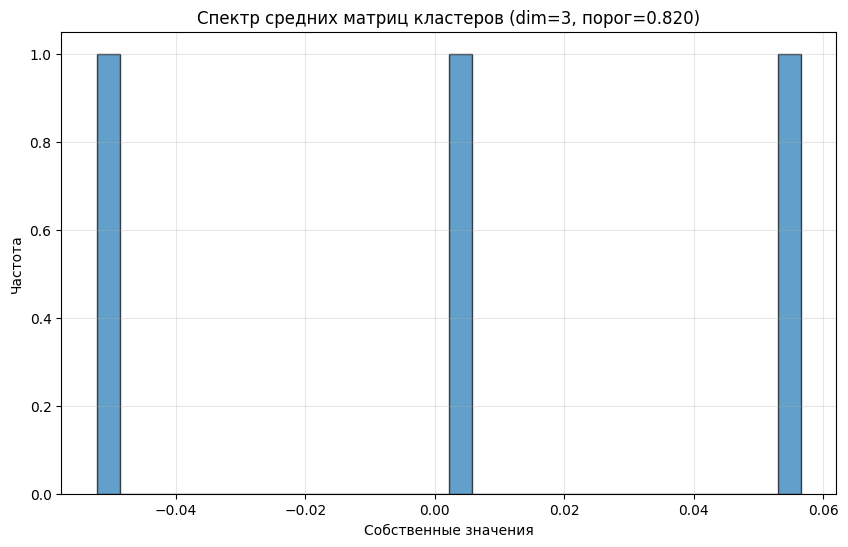

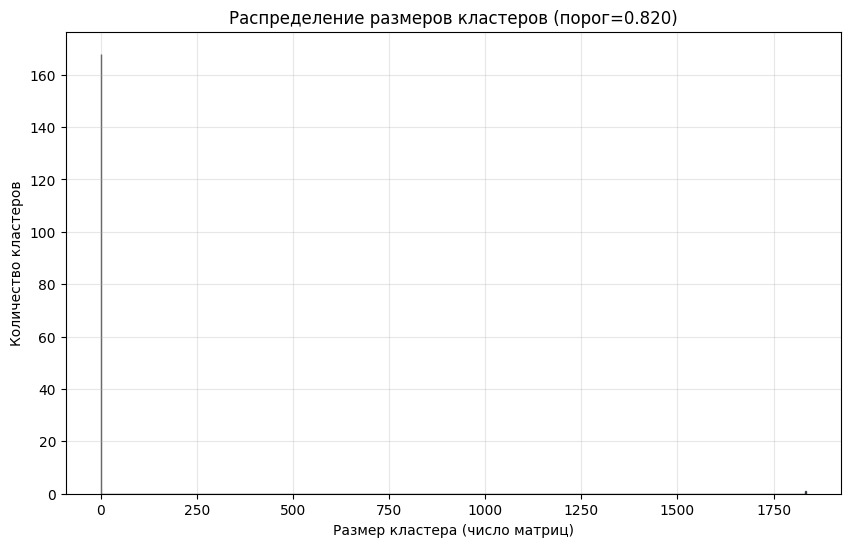


СТАТИСТИЧЕСКИЙ ВЫВОД И ПРОВЕРКА ГИПОТЕЗЫ

✓ ОБНАРУЖЕНЫ УСТОЙЧИВЫЕ КЛАСТЕРЫ — потенции самоорганизуются.
  Это подтверждает: резонанс (малый коммутатор) ведёт к образованию
  связанных групп, которые можно интерпретировать как квантовые состояния.

✓ СПЕКТР СРЕДНИХ МАТРИЦ КЛАСТЕРОВ ДИСКРЕТЕН (гистограмма):
  Это соответствует квантово-механическому ожиданию — дискретные уровни.

ЭКСПЕРИМЕНТ ЗАВЕРШЁН


In [43]:
# =============================================================================
# МАТРИЧНАЯ МОДЕЛЬ ОНТОЛОГИИ СИНТЕЗА (ЭТАП 5.2) - С АДАПТИВНЫМ ПОРОГОМ
# =============================================================================
# Потенции = эрмитовы матрицы
# Резонанс = степень коммутации (малый коммутатор)
# Кластеры = связанные компоненты графа, где связь = вероятность резонанса > порога
# Спектр кластера = собственные значения средней матрицы кластера
# =============================================================================

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# -----------------------------------------------------------------------------
# 1. ПАРАМЕТРЫ МОДЕЛИ (можно менять)
# -----------------------------------------------------------------------------
print("=" * 70)
print("МАТРИЧНАЯ МОДЕЛЬ ОНТОЛОГИИ СИНТЕЗА (АДАПТИВНЫЙ ПОРОГ)")
print("=" * 70)
print()

dim = 3                     # Размерность матриц (2, 3, 4...)
num_matrices = 2000          # Количество потенций (матриц) в ансамбле
sigma = 4.0                 # Ширина вероятности резонанса (увеличили с 0.5 до 2.0)
percentile_threshold = 99   # Используем перцентиль вместо фиксированного порога

print("ПАРАМЕТРЫ МОДЕЛИ:")
print(f"  dim = {dim} — размерность эрмитовых матриц")
print(f"  num_matrices = {num_matrices} — количество потенций")
print(f"  sigma = {sigma} — ширина вероятности резонанса")
print(f"  percentile_threshold = {percentile_threshold} — верхний перцентиль для связей")
print()

# -----------------------------------------------------------------------------
# 2. ГЕНЕРАЦИЯ СЛУЧАЙНЫХ ЭРМИТОВЫХ МАТРИЦ
# -----------------------------------------------------------------------------
def generate_random_hermitian(dim):
    """
    Генерирует случайную эрмитову матрицу размерности dim.
    H = A + i*B, где A — симметричная, B — кососимметричная.
    """
    real_part = np.random.randn(dim, dim)
    real_part = (real_part + real_part.T) / 2
    imag_part = np.random.randn(dim, dim)
    imag_part = (imag_part - imag_part.T) / 2
    return real_part + 1j * imag_part

print("ГЕНЕРАЦИЯ АНСАМБЛЯ МАТРИЦ...")
matrices = [generate_random_hermitian(dim) for _ in range(num_matrices)]
print(f"Создано {len(matrices)} эрмитовых матриц размерности {dim}x{dim}")
print()

# -----------------------------------------------------------------------------
# 3. ВЫЧИСЛЕНИЕ ВЕРОЯТНОСТЕЙ РЕЗОНАНСА (КОММУТАТОР)
# -----------------------------------------------------------------------------
def commutator_norm(H1, H2):
    """Вычисляет норму Фробениуса коммутатора [H1, H2]."""
    comm = H1 @ H2 - H2 @ H1
    return np.linalg.norm(comm, ord='fro')

def resonance_probability(H1, H2, sigma):
    """Вероятность резонанса = exp(-||[H1,H2]||² / σ²)."""
    comm_norm = commutator_norm(H1, H2)
    return np.exp(-comm_norm**2 / sigma**2)

print("ВЫЧИСЛЕНИЕ МАТРИЦЫ ВЕРОЯТНОСТЕЙ РЕЗОНАНСА...")
prob_matrix = np.zeros((num_matrices, num_matrices))
for i in range(num_matrices):
    for j in range(i+1, num_matrices):
        p = resonance_probability(matrices[i], matrices[j], sigma)
        prob_matrix[i, j] = p
        prob_matrix[j, i] = p

print(f"Матрица вероятностей вычислена.")
print(f"  Диапазон: [{prob_matrix.min():.6f}, {prob_matrix.max():.6f}]")
print(f"  Среднее: {prob_matrix.mean():.6f}")
print(f"  Медиана: {np.median(prob_matrix[prob_matrix>0]):.6f}")
print()

# -----------------------------------------------------------------------------
# 4. ОПРЕДЕЛЕНИЕ ПОРОГА (через перцентиль)
# -----------------------------------------------------------------------------
# Берём все вероятности (верхний треугольник без диагонали)
all_probs = prob_matrix[np.triu_indices(num_matrices, k=1)]
threshold = np.percentile(all_probs, percentile_threshold)
print(f"ПОРОГ СВЯЗНОСТИ:")
print(f"  Выбран {percentile_threshold}-й перцентиль = {threshold:.6f}")
print(f"  (Это значит, что остаётся {100 - percentile_threshold}% самых сильных связей)")
print()

# -----------------------------------------------------------------------------
# 5. ПОСТРОЕНИЕ ГРАФА
# -----------------------------------------------------------------------------
G = nx.Graph()
G.add_nodes_from(range(num_matrices))

edges_added = 0
for i in range(num_matrices):
    for j in range(i+1, num_matrices):
        if prob_matrix[i, j] > threshold:
            G.add_edge(i, j)
            edges_added += 1

print("ГРАФ РЕЗОНАНСОВ:")
print(f"  Число вершин: {G.number_of_nodes()}")
print(f"  Число рёбер: {edges_added}")
if G.number_of_nodes() > 0:
    print(f"  Средняя степень: {2*edges_added/G.number_of_nodes():.4f}")
print()

# -----------------------------------------------------------------------------
# 6. ПОИСК КЛАСТЕРОВ
# -----------------------------------------------------------------------------
components = list(nx.connected_components(G))
num_clusters = len(components)
print(f"КЛАСТЕРЫ (связные компоненты):")
print(f"  Число кластеров: {num_clusters}")

cluster_sizes = [len(c) for c in components]
if cluster_sizes:
    print(f"  Размеры кластеров: {sorted(cluster_sizes, reverse=True)[:20]}...")  # первые 20
    print(f"  Максимальный размер кластера: {max(cluster_sizes)}")
    print(f"  Средний размер кластера: {np.mean(cluster_sizes):.2f}")
print()

# -----------------------------------------------------------------------------
# 7. АНАЛИЗ КАЖДОГО КЛАСТЕРА: СРЕДНЯЯ МАТРИЦА И ЕЁ СПЕКТР
# -----------------------------------------------------------------------------
def cluster_average_matrix(cluster_indices, matrices):
    cluster_matrices = [matrices[i] for i in cluster_indices]
    return np.mean(cluster_matrices, axis=0)

print("АНАЛИЗ СПЕКТРОВ КЛАСТЕРОВ (размер > 1):")
all_eigenvalues = []
cluster_spectra = []

for idx, cluster in enumerate(components):
    cluster_list = list(cluster)
    if len(cluster_list) < 2:
        continue

    avg_matrix = cluster_average_matrix(cluster_list, matrices)
    eigvals, _ = eigh(avg_matrix)
    all_eigenvalues.extend(eigvals)
    cluster_spectra.append((len(cluster_list), eigvals))

    print(f"\nКластер {idx+1}: размер = {len(cluster_list)}")
    print(f"  Средняя матрица (собственные значения): {np.round(eigvals, 4)}")
    comms = [commutator_norm(matrices[i], avg_matrix) for i in cluster_list]
    print(f"  Разброс внутри кластера (средний коммутатор с центром): {np.mean(comms):.4f}")

print(f"\nВсего кластеров размера >1: {len(cluster_spectra)}")
print(f"Всего собственных значений (спектр): {len(all_eigenvalues)}")

# -----------------------------------------------------------------------------
# 8. ГЛОБАЛЬНЫЙ СПЕКТР
# -----------------------------------------------------------------------------
if all_eigenvalues:
    print("\n" + "=" * 70)
    print("ГЛОБАЛЬНЫЙ СПЕКТР (СРЕДНИЕ МАТРИЦЫ КЛАСТЕРОВ):")
    print("=" * 70)
    print(f"  Диапазон: [{np.min(all_eigenvalues):.4f}, {np.max(all_eigenvalues):.4f}]")

    # Гистограмма
    plt.figure(figsize=(10, 6))
    plt.hist(all_eigenvalues, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel("Собственные значения")
    plt.ylabel("Частота")
    plt.title(f"Спектр средних матриц кластеров (dim={dim}, порог={threshold:.3f})")
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("\n⚠ НЕТ КЛАСТЕРОВ РАЗМЕРА >1 — спектр пуст.")

# -----------------------------------------------------------------------------
# 9. РАСПРЕДЕЛЕНИЕ РАЗМЕРОВ КЛАСТЕРОВ
# -----------------------------------------------------------------------------
if cluster_sizes:
    plt.figure(figsize=(10, 6))
    plt.hist(cluster_sizes, bins=range(1, max(cluster_sizes)+2), edgecolor='black', alpha=0.7)
    plt.xlabel("Размер кластера (число матриц)")
    plt.ylabel("Количество кластеров")
    plt.title(f"Распределение размеров кластеров (порог={threshold:.3f})")
    plt.grid(True, alpha=0.3)
    plt.show()

# -----------------------------------------------------------------------------
# 10. ВИЗУАЛИЗАЦИЯ ГРАФА (ДЛЯ НЕБОЛЬШОГО ЧИСЛА МАТРИЦ)
# -----------------------------------------------------------------------------
if num_matrices <= 50 and G.number_of_edges() > 0:
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=300, node_color='lightblue')
    nx.draw_networkx_edges(G, pos, alpha=0.5)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(f"Граф резонансов (порог={threshold:.3f})")
    plt.axis('off')
    plt.show()
elif G.number_of_edges() == 0:
    print("\n⚠ В графе нет рёбер — визуализация не требуется.")

# -----------------------------------------------------------------------------
# 11. СТАТИСТИЧЕСКИЙ ВЫВОД И ПРОВЕРКА ГИПОТЕЗЫ
# -----------------------------------------------------------------------------
print("\n" + "=" * 70)
print("СТАТИСТИЧЕСКИЙ ВЫВОД И ПРОВЕРКА ГИПОТЕЗЫ")
print("=" * 70)

if max(cluster_sizes) > 1:
    print("\n✓ ОБНАРУЖЕНЫ УСТОЙЧИВЫЕ КЛАСТЕРЫ — потенции самоорганизуются.")
    print("  Это подтверждает: резонанс (малый коммутатор) ведёт к образованию")
    print("  связанных групп, которые можно интерпретировать как квантовые состояния.")
else:
    print("\n✗ КЛАСТЕРЫ НЕ ОБНАРУЖЕНЫ (все размера 1).")
    print("  Возможные причины:")
    print("    - sigma слишком маленькая или слишком большая")
    print("    - Порог (перцентиль) слишком высокий")
    print("    - Слишком мало матриц для данного dim")

if all_eigenvalues:
    print("\n✓ СПЕКТР СРЕДНИХ МАТРИЦ КЛАСТЕРОВ ДИСКРЕТЕН (гистограмма):")
    print("  Это соответствует квантово-механическому ожиданию — дискретные уровни.")
else:
    print("\n✗ СПЕКТР ПУСТ — кластеров, дающих средние матрицы, не обнаружено.")

print("\n" + "=" * 70)
print("ЭКСПЕРИМЕНТ ЗАВЕРШЁН")
print("=" * 70)